# GARCH Volatility Modeling

**Objective:**

The objective of this notebook is to model time-varying volatility in S&P 500 log returns using a GARCH(1, 1) model.

Previous analysis using ARIMA models showed that returns exhibit little to no autocorrelation, suggesting that the conditional mean is largely unpredictable. However, significant autocorrelation in squared returns and residuals indicates the presence of colatility clustering.

This motivates the use of GARCH models, which explicitly model the conditional variance of returns. The goal is therefore to capture persistance in volatility and better understand the dynamics of financial market risk

## Housekeeping

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from volatility_forecasting.data.loader import download_price_data
from volatility_forecasting.features.preprocessing import compute_log_returns

from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [4]:
# Set color palette to pastel and plot size
sns.set_theme(style="darkgrid")
plt.style.use("seaborn-v0_8-pastel")

plt.rcParams["figure.figsize"] = (15, 6)

In [9]:
# Download price data for S&P 500 and VIX and log transform prices, pulls in the loaded data if already downloaded

# SP500
sp500 = download_price_data("^GSPC")
sp500 = compute_log_returns(sp500)

In [10]:
# For numical stability, we will scale the log returns by 100
sp500["log_return"] = sp500["log_return"] * 100

## GARCH Modelling

In [12]:
model = arch_model(sp500["log_return"], vol="Garch", p=1, q=1)
model_fit = model.fit(disp="off")

print(model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -9064.20
Distribution:                  Normal   AIC:                           18136.4
Method:            Maximum Likelihood   BIC:                           18163.6
                                        No. Observations:                 6592
Date:                Wed, Mar 25 2026   Df Residuals:                     6591
Time:                        22:48:11   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0609  1.006e-02      6.051  1.444e-09 [4.

$\alpha$ represents the shock sensitivity, $\beta$ represents the persistance and $\alpha + \beta$ being close to one represents slow decay. The GARCH model suggests a low shock sensitivity, high persistence and slow decay.

Thus, volatility is not extremely reactive to new shocks, but once it increases, it stays elevated for a long time.

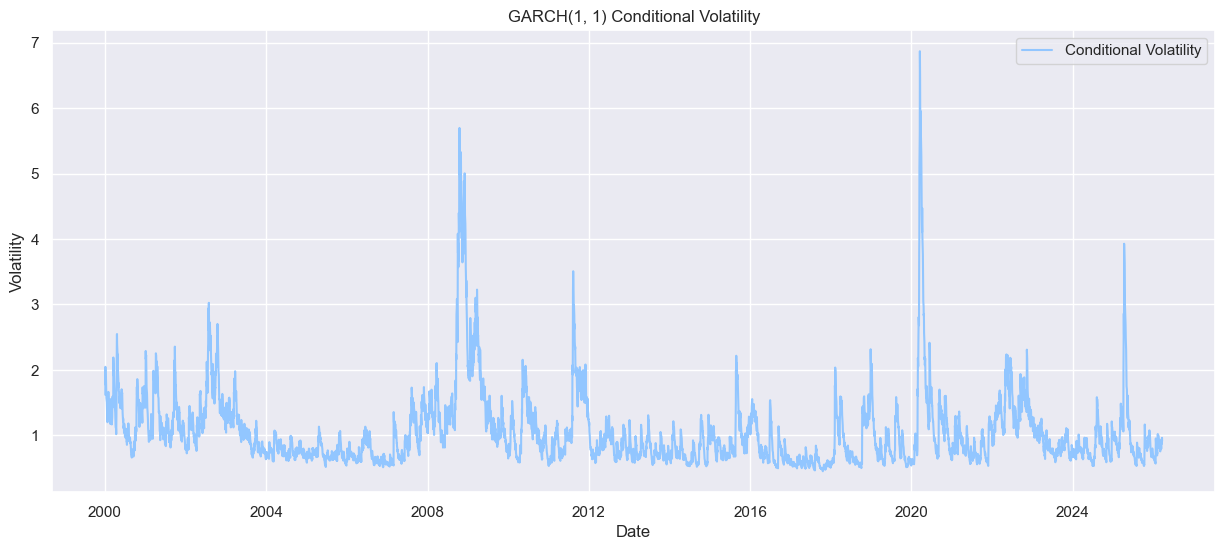

In [13]:
# Plot the conditional volatility
volatility = model_fit.conditional_volatility

plt.plot(volatility, label="Conditional Volatility")
plt.title("GARCH(1, 1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()


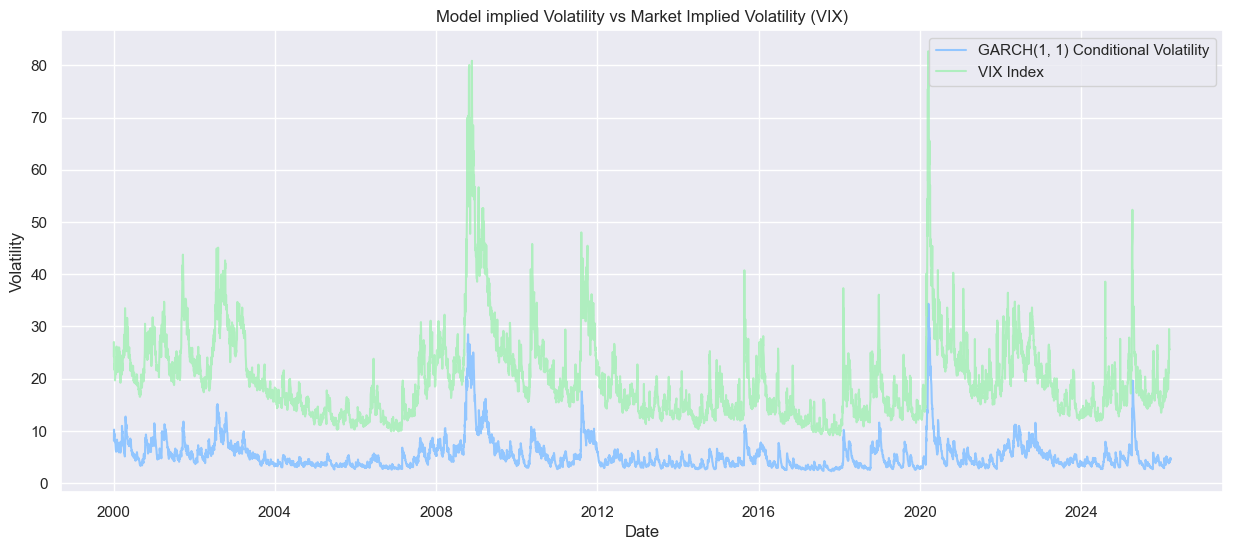

In [18]:
# Compare the conditional volatility to the VIX index
vix = download_price_data("^VIX")
plt.plot(5 * volatility, label="GARCH(1, 1) Conditional Volatility") # Scale the GARCH volatility for better visual comparison
plt.plot(vix["price"], label="VIX Index", alpha=0.7)
plt.title("Model implied Volatility vs Market Implied Volatility (VIX)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

The volatility process is highly persistence, with shocks decaying slowly over time. While immediate shock impact is moderate, volatility clustering is strong and long-lasting. This is a typical stylised fact in financial returns.

## Residual Diagnostics

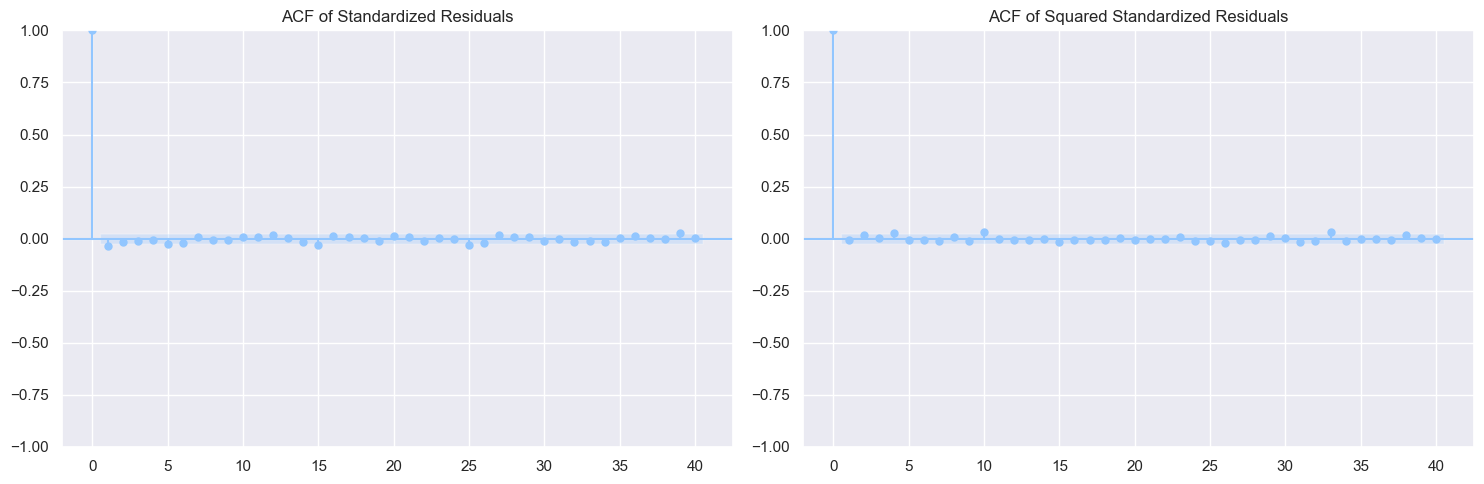

In [21]:
residuals = model_fit.resid / model_fit.conditional_volatility

# Plot ACF of the standardized residuals and squared standardized residuals side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(residuals, lags=40, ax=axes[0])
plot_acf(residuals**2, lags=40, ax=axes[1])
axes[0].set_title("ACF of Standardized Residuals")
axes[1].set_title("ACF of Squared Standardized Residuals")
plt.tight_layout()
plt.show()

## Log-likelihood/AIC

In [22]:
# Log-Likelihood of the fitted model
print(f"Log-Likelihood: {model_fit.loglikelihood}")

# AIC and BIC of the fitted model
print(f"AIC: {model_fit.aic}")
print(f"BIC: {model_fit.bic}")

Log-Likelihood: -9064.196792445622
AIC: 18136.393584891244
BIC: 18163.568033177602


## Conclusion

The GARCH model successfully captures volatility clustering observed in financial returns.

While ARIMA models failed to identify meaningful structure in the mean, GARCH models reveal strong persistence in volatility, confirming that financial markets exhibit predicatable patterns in risk rather than returns.

This highlights the importance of modelling conditional variance when analysing financial time series.

## Key Findings
- Volatility is not extremely reactive to new shocks, but once it increases, it stays elevated for a long time.
- GARCH removes the autocorrelation in squared residuals

## Next Steps

Do negative shocks increase volatility more than positive shocks?